# Projet Deep Learning EMSI — Partie III : RNN, LSTM, GRU & Seq2Seq
## Analyse de Reviews Médicales — UCI Drug Reviews
**Année 2025-2026** | **Thème : Santé**

---
### Plan
1. Modèles de langage & perplexité
2. Chargement & prétraitement des données
3. Implémentation RNN
4. Implémentation LSTM
5. Implémentation GRU
6. BPTT & gradient clipping
7. Comparaison RNN / LSTM / GRU
8. Architecture Seq2Seq (encodeur-décodeur)
9. Décodage glouton & Beam Search
10. Évaluation (Perplexité & BLEU)
11. Question de synthèse

In [1]:
# ── Imports & Setup ──────────────────────────────────────────
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'datasets', 'nltk', '-q'])

import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import numpy as np, matplotlib.pyplot as plt
import re, math, random, collections
from datasets import load_dataset
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
import warnings; warnings.filterwarnings('ignore')

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch : {torch.__version__}  |  Device : {device}')

PyTorch : 2.11.0+cu128  |  Device : cuda


## 1. Modèles de langage & Perplexité

### Objectif probabiliste
Un modèle de langage attribue une probabilité à une séquence de tokens :
$$P(x_1, x_2, \ldots, x_T) = \prod_{t=1}^{T} P(x_t \mid x_1, \ldots, x_{t-1})$$

L'idée fondatrice : **prédire le prochain token à partir du passé**.

### Perplexité
$$\text{PPL} = \exp\left(-\frac{1}{T}\sum_{t=1}^T \log P(x_t \mid x_{<t})\right)$$
- PPL faible → modèle certain → bon
- PPL élevée → modèle hésite → mauvais
- Équivalent à `exp(cross_entropy_loss)` en PyTorch

### Approches n-grammes vs réseaux récurrents
| Critère | N-grammes | RNN |
|---------|-----------|-----|
| Contexte | Limité à n-1 tokens | Théoriquement illimité |
| Paramètres | Exponentiels | Fixes |
| Généralisation | Faible (sparsité) | Bonne |

In [2]:
# ── Chargement UCI Drug Reviews ──────────────────────────────
print('Chargement dataset...')
raw = load_dataset('lewtun/drug-reviews', split='train')
# On garde uniquement les colonnes utiles
reviews  = [r['review'] for r in raw if isinstance(r['review'], str) and len(r['review']) > 20]
conditions = [r['condition'] for r in raw if isinstance(r['review'], str) and len(r['review']) > 20]
ratings  = [int(r['rating']) for r in raw if isinstance(r['review'], str) and len(r['review']) > 20]

# Sous-ensemble pour rapidité d'entraînement
N = 8000
indices = random.sample(range(len(reviews)), min(N, len(reviews)))
reviews    = [reviews[i] for i in indices]
conditions = [conditions[i] for i in indices]
ratings    = [ratings[i]  for i in indices]

print(f'Exemples chargés : {len(reviews)}')
print(f'Exemple review   : {reviews[0][:120]}...')
print(f'Condition        : {conditions[0]}')
print(f'Rating           : {ratings[0]}/10')

Chargement dataset...


train.jsonl:   0%|          | 0.00/97.7M [00:00<?, ?B/s]

test.jsonl:   0%|          | 0.00/32.5M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/161297 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/53766 [00:00<?, ? examples/s]

Exemples chargés : 8000
Exemple review   : "This is the first time I&#039;ve taken a diet pill that didn&#039;t leave me jittery or with balloon-head syndrome. I w...
Condition        : Obesity
Rating           : 9/10


Longueur moy : 87.0  |  max : 349  |  min : 2


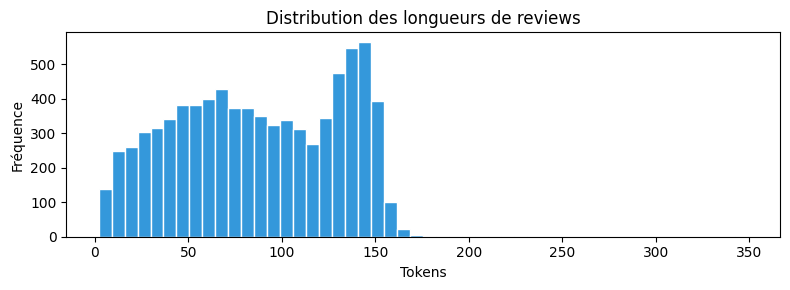

In [3]:
# ── Nettoyage & Tokenisation ─────────────────────────────────
def clean_text(text):
    text = text.lower()
    text = re.sub(r'&#[0-9]+;', ' ', text)  # entités HTML
    text = re.sub(r'[^a-z0-9\s.,!?]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def simple_tokenize(text):
    return text.split()

cleaned = [clean_text(r) for r in reviews]
tokenized = [simple_tokenize(r) for r in cleaned]

# Longueurs
lengths = [len(t) for t in tokenized]
print(f'Longueur moy : {np.mean(lengths):.1f}  |  max : {max(lengths)}  |  min : {min(lengths)}')

plt.figure(figsize=(8, 3))
plt.hist(lengths, bins=50, color='#3498db', edgecolor='white')
plt.title('Distribution des longueurs de reviews')
plt.xlabel('Tokens'); plt.ylabel('Fréquence'); plt.tight_layout(); plt.show()

In [4]:
# ── Construction du vocabulaire ──────────────────────────────
PAD, BOS, EOS, UNK = '<pad>', '<bos>', '<eos>', '<unk>'

counter = collections.Counter(token for seq in tokenized for token in seq)
VOCAB_SIZE = 5000
vocab_tokens = [PAD, BOS, EOS, UNK] + [w for w, _ in counter.most_common(VOCAB_SIZE - 4)]
word2idx = {w: i for i, w in enumerate(vocab_tokens)}
idx2word = {i: w for w, i in word2idx.items()}

def encode(seq, max_len=50):
    ids = [word2idx.get(w, word2idx[UNK]) for w in seq[:max_len]]
    ids = ids + [word2idx[PAD]] * (max_len - len(ids))
    return ids

print(f'Taille vocabulaire : {len(word2idx)}')
print(f'PAD={word2idx[PAD]}  BOS={word2idx[BOS]}  EOS={word2idx[EOS]}  UNK={word2idx[UNK]}')

Taille vocabulaire : 5000
PAD=0  BOS=1  EOS=2  UNK=3


In [5]:
# ── Dataset PyTorch ──────────────────────────────────────────
MAX_LEN = 50
SPLIT = int(0.85 * len(tokenized))

class ReviewDataset(Dataset):
    def __init__(self, seqs, labels):
        self.X = [torch.tensor(encode(s, MAX_LEN), dtype=torch.long) for s in seqs]
        # Longueurs réelles (avant padding) pour pack_padded_sequence
        self.lengths = [min(len(s), MAX_LEN) for s in seqs]
        self.y = torch.tensor(labels, dtype=torch.long)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, i):
        return self.X[i], self.y[i], self.lengths[i]

# Sentiment binaire : rating >= 7 → positif (1), sinon négatif (0)
bin_ratings = [1 if r >= 7 else 0 for r in ratings]

train_ds = ReviewDataset(tokenized[:SPLIT], bin_ratings[:SPLIT])
test_ds  = ReviewDataset(tokenized[SPLIT:], bin_ratings[SPLIT:])
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False)

pos = sum(bin_ratings)
print(f'Train : {len(train_ds)}  |  Test : {len(test_ds)}')
print(f'Positifs : {pos} ({100*pos/len(bin_ratings):.1f}%)  Négatifs : {len(bin_ratings)-pos}')
print(f'[Masquage] Les longueurs réelles sont transmises pour pack_padded_sequence')

Train : 6800  |  Test : 1200
Positifs : 5310 (66.4%)  Négatifs : 2690
[Masquage] Les longueurs réelles sont transmises pour pack_padded_sequence


## 2. RNN — Réseau de Neurones Récurrent

**Équations :**
$$h_t = \phi(W_{xh}x_t + W_{hh}h_{t-1} + b_h)$$
$$\hat{y} = \text{softmax}(W_{hq}h_T + b_q)$$

L'**état caché** $h_t$ résume tout le contexte passé.  
Problème : **gradient évanescent** sur longues séquences.

In [6]:
# ── RNN pour classification de sentiment ─────────────────────
class RNNClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_size=128, num_classes=2, num_layers=1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn = nn.RNN(embed_dim, hidden_size, num_layers=num_layers,
                          batch_first=True, nonlinearity='tanh')
        self.fc = nn.Linear(hidden_size, num_classes)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x, lengths=None):
        emb = self.dropout(self.embedding(x))
        if lengths is not None:
            # Masquage correct : ignore les tokens de padding dans le RNN
            packed = nn.utils.rnn.pack_padded_sequence(
                emb, lengths.cpu(), batch_first=True, enforce_sorted=False)
            _, hn = self.rnn(packed)
        else:
            _, hn = self.rnn(emb)
        out = self.fc(self.dropout(hn[-1]))
        return out

rnn_model = RNNClassifier(len(word2idx)).to(device)
print(rnn_model)
n = sum(p.numel() for p in rnn_model.parameters() if p.requires_grad)
print(f'Paramètres : {n:,}')

RNNClassifier(
  (embedding): Embedding(5000, 64, padding_idx=0)
  (rnn): RNN(64, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=2, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)
Paramètres : 345,090


## 3. BPTT & Gradient Clipping

### Backpropagation Through Time (BPTT)
Le RNN est **déplié dans le temps** : une copie du bloc récurrent par instant $t$.  
Le gradient traverse tous les pas temporels :
$$\frac{\partial L}{\partial h_k} = \sum_{t \geq k} \frac{\partial L}{\partial h_t} \prod_{i=k+1}^{t} \frac{\partial h_i}{\partial h_{i-1}}$$

- **Gradient évanescent** : produit → 0 → RNN oublie le contexte lointain
- **Gradient explosif** : produit → ∞ → instabilité numérique

### Gradient Clipping
Si $\|g\| > \theta$ : $g \leftarrow \theta \cdot g / \|g\|$
```python
torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
```

In [7]:
# ── Boucle d'entraînement avec gradient clipping ─────────────
def train_classifier(model, epochs=10, lr=1e-3, clip=1.0, name='Model'):
    opt = optim.Adam(model.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()
    history = {'train_acc':[], 'test_acc':[], 'train_loss':[]}

    for epoch in range(epochs):
        model.train()
        losses, preds, labels = [], [], []
        for xb, yb, lb in train_loader:               # lb = longueurs réelles
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            out = model(xb, lb)                        # masquage via pack_padded_sequence
            loss = crit(out, yb)
            loss.backward()
            # Gradient clipping (illustre l'effet du BPTT sur les séquences longues)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip)
            opt.step()
            losses.append(loss.item())
            preds  += out.argmax(1).cpu().tolist()
            labels += yb.cpu().tolist()

        model.eval()
        t_preds, t_labels = [], []
        with torch.no_grad():
            for xb, yb, lb in test_loader:
                xb, yb = xb.to(device), yb.to(device)
                t_preds  += model(xb, lb).argmax(1).cpu().tolist()
                t_labels += yb.cpu().tolist()

        from sklearn.metrics import accuracy_score
        tr_acc = accuracy_score(labels, preds)
        te_acc = accuracy_score(t_labels, t_preds)
        history['train_acc'].append(tr_acc)
        history['test_acc'].append(te_acc)
        history['train_loss'].append(np.mean(losses))
        if (epoch+1) % 3 == 0:
            print(f'[{name}] Ep {epoch+1:2d}/{epochs} | Loss={np.mean(losses):.4f} | Train={tr_acc:.4f} | Test={te_acc:.4f}')

    return history

## 4. LSTM — Long Short-Term Memory

Introduit un **état de cellule** $c_t$ et des **portes** pour gérer la mémoire à long terme :

$$f_t = \sigma(W_f x_t + U_f h_{t-1} + b_f) \quad \text{(porte d'oubli)}$$
$$i_t = \sigma(W_i x_t + U_i h_{t-1} + b_i) \quad \text{(porte d'entrée)}$$
$$\tilde{c}_t = \tanh(W_c x_t + U_c h_{t-1} + b_c) \quad \text{(candidat)}$$
$$c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t \quad \text{(état de cellule)}$$
$$o_t = \sigma(W_o x_t + U_o h_{t-1} + b_o) \quad \text{(porte de sortie)}$$
$$h_t = o_t \odot \tanh(c_t)$$

Le chemin $c_t$ offre un **gradient plus stable** (moins d'évanouissement).

In [8]:
# ── LSTM Classifier ──────────────────────────────────────────
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_size=128, num_classes=2, num_layers=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_size, num_layers=num_layers,
                            batch_first=True, dropout=0.3)
        self.fc = nn.Linear(hidden_size, num_classes)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x, lengths=None):
        emb = self.dropout(self.embedding(x))
        if lengths is not None:
            packed = nn.utils.rnn.pack_padded_sequence(
                emb, lengths.cpu(), batch_first=True, enforce_sorted=False)
            _, (hn, _) = self.lstm(packed)
        else:
            _, (hn, _) = self.lstm(emb)
        return self.fc(self.dropout(hn[-1]))

lstm_model = LSTMClassifier(len(word2idx)).to(device)
print(f'LSTM params : {sum(p.numel() for p in lstm_model.parameters()):,}')

LSTM params : 551,682


## 5. GRU — Gated Recurrent Unit

Simplifie le LSTM avec **2 portes** et pas d'état de cellule séparé :

$$z_t = \sigma(W_z x_t + U_z h_{t-1}) \quad \text{(mise à jour)}$$
$$r_t = \sigma(W_r x_t + U_r h_{t-1}) \quad \text{(réinitialisation)}$$
$$\tilde{h}_t = \tanh(W_h x_t + U_h(r_t \odot h_{t-1}))$$
$$h_t = z_t \odot h_{t-1} + (1-z_t) \odot \tilde{h}_t$$

**Plus léger** que LSTM, performance souvent équivalente.

In [9]:
# ── GRU Classifier ───────────────────────────────────────────
class GRUClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_size=128, num_classes=2, num_layers=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.gru = nn.GRU(embed_dim, hidden_size, num_layers=num_layers,
                          batch_first=True, dropout=0.3)
        self.fc = nn.Linear(hidden_size, num_classes)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x, lengths=None):
        emb = self.dropout(self.embedding(x))
        if lengths is not None:
            packed = nn.utils.rnn.pack_padded_sequence(
                emb, lengths.cpu(), batch_first=True, enforce_sorted=False)
            _, hn = self.gru(packed)
        else:
            _, hn = self.gru(emb)
        return self.fc(self.dropout(hn[-1]))

gru_model = GRUClassifier(len(word2idx)).to(device)
print(f'GRU params : {sum(p.numel() for p in gru_model.parameters()):,}')

GRU params : 493,826


In [10]:
# ── Entraînement et comparaison RNN / LSTM / GRU ─────────────
EPOCHS = 10
print('--- RNN ---')
hist_rnn  = train_classifier(rnn_model,  EPOCHS, name='RNN')
print('--- LSTM ---')
hist_lstm = train_classifier(lstm_model, EPOCHS, name='LSTM')
print('--- GRU ---')
hist_gru  = train_classifier(gru_model,  EPOCHS, name='GRU')

--- RNN ---
[RNN] Ep  3/10 | Loss=0.6274 | Train=0.6650 | Test=0.6467
[RNN] Ep  6/10 | Loss=0.6029 | Train=0.6804 | Test=0.6492
[RNN] Ep  9/10 | Loss=0.5710 | Train=0.7151 | Test=0.6625
--- LSTM ---
[LSTM] Ep  3/10 | Loss=0.6106 | Train=0.6704 | Test=0.6600
[LSTM] Ep  6/10 | Loss=0.5301 | Train=0.7375 | Test=0.6650
[LSTM] Ep  9/10 | Loss=0.4264 | Train=0.8081 | Test=0.6908
--- GRU ---
[GRU] Ep  3/10 | Loss=0.6151 | Train=0.6757 | Test=0.6258
[GRU] Ep  6/10 | Loss=0.5326 | Train=0.7376 | Test=0.6783
[GRU] Ep  9/10 | Loss=0.4510 | Train=0.7896 | Test=0.6775


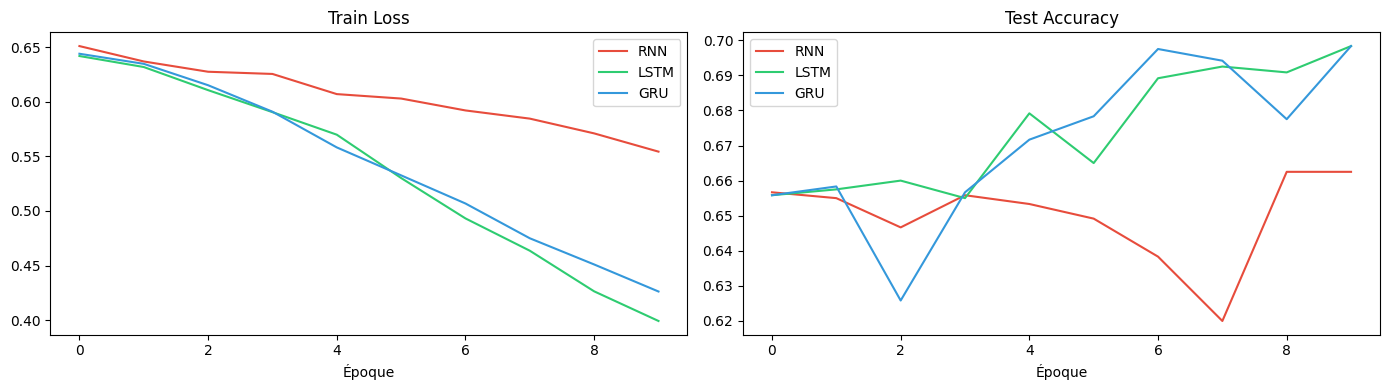


Comparaison finale :
  RNN  → Test Acc = 0.6625
  LSTM → Test Acc = 0.6983
  GRU  → Test Acc = 0.6983


In [11]:
# ── Comparaison visuelle ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for name, hist, c in [('RNN', hist_rnn,'#e74c3c'),('LSTM', hist_lstm,'#2ecc71'),('GRU', hist_gru,'#3498db')]:
    axes[0].plot(hist['train_loss'], label=name, color=c)
    axes[1].plot(hist['test_acc'],   label=name, color=c)
axes[0].set_title('Train Loss'); axes[0].legend(); axes[0].set_xlabel('Époque')
axes[1].set_title('Test Accuracy'); axes[1].legend(); axes[1].set_xlabel('Époque')
plt.tight_layout(); plt.show()

print('\nComparaison finale :')
for name, hist in [('RNN',hist_rnn),('LSTM',hist_lstm),('GRU',hist_gru)]:
    print(f'  {name:4s} → Test Acc = {hist["test_acc"][-1]:.4f}')

## 6. Architecture Seq2Seq — Encodeur-Décodeur

**Tâche :** Review médicale (texte) → Sentiment sous forme de séquence générée

**Architecture :**
```
Encodeur : GRU bidirectionnel → état caché condensé
Décodeur : GRU + projection → génère token par token
```
**Teacher forcing :** pendant l'entraînement, on donne le token correct à chaque pas,
même si la prédiction précédente était fausse → apprentissage plus stable.

In [12]:
# ── Seq2Seq : Encodeur ───────────────────────────────────────
class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_size=128, num_layers=1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.gru = nn.GRU(embed_dim, hidden_size, num_layers=num_layers,
                          batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_size * 2, hidden_size)

    def forward(self, src):
        emb = self.embedding(src)
        _, hidden = self.gru(emb)
        # Concatène les 2 directions
        hidden = torch.cat([hidden[-2], hidden[-1]], dim=1)
        hidden = torch.tanh(self.fc(hidden)).unsqueeze(0)
        return hidden

# ── Seq2Seq : Décodeur ────────────────────────────────────────
class Decoder(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_size=128, num_layers=1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.gru = nn.GRU(embed_dim, hidden_size, num_layers=num_layers, batch_first=True)
        self.fc_out = nn.Linear(hidden_size, vocab_size)

    def forward(self, tgt_token, hidden):
        emb = self.embedding(tgt_token.unsqueeze(1))
        out, hidden = self.gru(emb, hidden)
        pred = self.fc_out(out.squeeze(1))
        return pred, hidden

# ── Modèle Seq2Seq complet ────────────────────────────────────
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        batch_size, tgt_len = tgt.shape
        vocab_size = self.decoder.fc_out.out_features
        outputs = torch.zeros(batch_size, tgt_len, vocab_size).to(src.device)
        hidden = self.encoder(src)
        input_token = tgt[:, 0]
        for t in range(1, tgt_len):
            pred, hidden = self.decoder(input_token, hidden)
            outputs[:, t] = pred
            teacher_force = random.random() < teacher_forcing_ratio
            input_token = tgt[:, t] if teacher_force else pred.argmax(1)
        return outputs

HIDDEN = 128
enc = Encoder(len(word2idx), hidden_size=HIDDEN).to(device)
dec = Decoder(len(word2idx), hidden_size=HIDDEN).to(device)
seq2seq = Seq2Seq(enc, dec).to(device)
n_s2s = sum(p.numel() for p in seq2seq.parameters() if p.requires_grad)
print(f'Paramètres Seq2Seq : {n_s2s:,}')

Paramètres Seq2Seq : 1,541,384


In [13]:
# ── Préparation données Seq2Seq (review → résumé court) ──────
# Tâche : prédire les 8 premiers tokens de la review à partir des 50 premiers
# (exercice pédagogique Seq2Seq sur même corpus)
BOS_IDX = word2idx[BOS]
EOS_IDX = word2idx[EOS]
PAD_IDX = word2idx[PAD]
TGT_LEN = 10

class Seq2SeqDataset(Dataset):
    def __init__(self, seqs):
        self.src = [torch.tensor(encode(s, MAX_LEN), dtype=torch.long) for s in seqs]
        # Cible : début de séquence entouré de BOS/EOS
        self.tgt = []
        for s in seqs:
            ids = [BOS_IDX] + [word2idx.get(w, word2idx[UNK]) for w in s[:TGT_LEN-2]] + [EOS_IDX]
            ids = ids[:TGT_LEN] + [PAD_IDX] * (TGT_LEN - len(ids))
            self.tgt.append(torch.tensor(ids, dtype=torch.long))
    def __len__(self): return len(self.src)
    def __getitem__(self, i): return self.src[i], self.tgt[i]

s2s_train = DataLoader(Seq2SeqDataset(tokenized[:SPLIT]), batch_size=64, shuffle=True)
s2s_test  = DataLoader(Seq2SeqDataset(tokenized[SPLIT:]), batch_size=64, shuffle=False)
print(f'Seq2Seq Train batches : {len(s2s_train)}  |  Test batches : {len(s2s_test)}')

Seq2Seq Train batches : 107  |  Test batches : 19


In [14]:
# ── Entraînement Seq2Seq ─────────────────────────────────────
optimizer_s2s = optim.Adam(seq2seq.parameters(), lr=5e-4)
criterion_s2s = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
S2S_EPOCHS = 8
s2s_losses = []

for epoch in range(S2S_EPOCHS):
    seq2seq.train()
    epoch_loss = []
    for src, tgt in s2s_train:
        src, tgt = src.to(device), tgt.to(device)
        optimizer_s2s.zero_grad()
        output = seq2seq(src, tgt)
        # output : (batch, tgt_len, vocab)  tgt : (batch, tgt_len)
        output_flat = output[:, 1:].reshape(-1, len(word2idx))
        target_flat = tgt[:, 1:].reshape(-1)
        loss = criterion_s2s(output_flat, target_flat)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(seq2seq.parameters(), max_norm=1.0)
        optimizer_s2s.step()
        epoch_loss.append(loss.item())
    avg = np.mean(epoch_loss)
    ppl = math.exp(avg)
    s2s_losses.append(avg)
    print(f'Ep {epoch+1}/{S2S_EPOCHS} | Loss={avg:.4f} | Perplexité={ppl:.2f}')

Ep 1/8 | Loss=6.2435 | Perplexité=514.64
Ep 2/8 | Loss=5.0059 | Perplexité=149.29
Ep 3/8 | Loss=4.7869 | Perplexité=119.93
Ep 4/8 | Loss=4.5820 | Perplexité=97.71
Ep 5/8 | Loss=4.3798 | Perplexité=79.82
Ep 6/8 | Loss=4.2087 | Perplexité=67.27
Ep 7/8 | Loss=4.0427 | Perplexité=56.98
Ep 8/8 | Loss=3.8842 | Perplexité=48.63


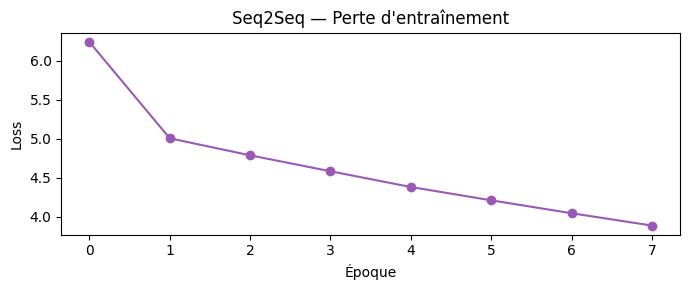

Perplexité finale : 48.63


In [15]:
# ── Courbe de perte Seq2Seq ──────────────────────────────────
plt.figure(figsize=(7, 3))
plt.plot(s2s_losses, marker='o', color='#9b59b6')
plt.title('Seq2Seq — Perte d\'entraînement'); plt.xlabel('Époque'); plt.ylabel('Loss')
plt.tight_layout(); plt.show()
print(f'Perplexité finale : {math.exp(s2s_losses[-1]):.2f}')

## 7. Décodage : Glouton vs Beam Search

### Décodage glouton
À chaque pas : $\hat{y}_t = \arg\max_{v} P(v \mid x, \hat{y}_{<t})$
Simple mais sous-optimal — un mauvais choix initial ne peut pas être corrigé.

### Beam Search
On maintient les **B meilleures hypothèses** (faisceaux) à chaque étape.
Plus coûteux mais produit de meilleures séquences.

In [16]:
# ── Décodage glouton ──────────────────────────────────────────
def greedy_decode(model, src, max_len=TGT_LEN):
    model.eval()
    with torch.no_grad():
        hidden = model.encoder(src.unsqueeze(0).to(device))
        token = torch.tensor([BOS_IDX]).to(device)
        result = []
        for _ in range(max_len):
            pred, hidden = model.decoder(token, hidden)
            token = pred.argmax(1)
            if token.item() == EOS_IDX:
                break
            result.append(idx2word.get(token.item(), UNK))
    return result

# ── Beam Search ───────────────────────────────────────────────
def beam_search_decode(model, src, beam_width=3, max_len=TGT_LEN):
    model.eval()
    with torch.no_grad():
        hidden = model.encoder(src.unsqueeze(0).to(device))
        beams = [(0.0, [BOS_IDX], hidden)]
        completed = []
        for _ in range(max_len):
            candidates = []
            for score, seq, h in beams:
                token = torch.tensor([seq[-1]]).to(device)
                pred, new_h = model.decoder(token, h)
                log_probs = torch.log_softmax(pred, dim=-1).squeeze()
                top_vals, top_ids = log_probs.topk(beam_width)
                for v, idx in zip(top_vals.tolist(), top_ids.tolist()):
                    candidates.append((score + v, seq + [idx], new_h))
            beams = sorted(candidates, key=lambda x: -x[0] / len(x[1]))[:beam_width]
            beams_new = []
            for s, seq, h in beams:
                if seq[-1] == EOS_IDX:
                    completed.append((s / len(seq), seq[1:-1]))
                else:
                    beams_new.append((s, seq, h))
            beams = beams_new if beams_new else beams
            if not beams:
                break
        if not completed:
            completed = [(beams[0][0], beams[0][1][1:])]
        best = max(completed, key=lambda x: x[0])
        return [idx2word.get(i, UNK) for i in best[1]]

# Test sur 3 exemples
print('Décodage sur exemples de test :\n')
for i in range(3):
    src_seq = test_ds[i][0]
    ref = [idx2word.get(t.item(), UNK) for t in src_seq if t.item() not in [PAD_IDX, BOS_IDX, EOS_IDX]][:8]
    greedy = greedy_decode(seq2seq, src_seq)
    beam   = beam_search_decode(seq2seq, src_seq)
    print(f'Référence   : {" ".join(ref)}')
    print(f'Glouton     : {" ".join(greedy)}')
    print(f'Beam Search : {" ".join(beam)}\n')

Décodage sur exemples de test :

Référence   : this drug was awful for me, i was
Glouton     : this was on this for for for i
Beam Search : this was on this for for i was <eos>

Référence   : i am 21 with a child and am
Glouton     : i am a a a a of <unk>
Beam Search : i am a a a a of <unk> <eos>

Référence   : removed all constipation, have regular bowel for the
Glouton     : it works it for for for me. i
Beam Search : it works it it it it it it <eos>



In [17]:
# ── Évaluation BLEU ──────────────────────────────────────────
references, hypotheses_greedy, hypotheses_beam = [], [], []
N_EVAL = min(200, len(test_ds))

for i in range(N_EVAL):
    src_seq = test_ds[i][0]
    ref = [idx2word.get(t.item(), UNK) for t in src_seq if t.item() not in [PAD_IDX, BOS_IDX, EOS_IDX]][:8]
    references.append([ref])
    hypotheses_greedy.append(greedy_decode(seq2seq, src_seq))
    hypotheses_beam.append(beam_search_decode(seq2seq, src_seq))

sf = SmoothingFunction().method1
bleu_greedy = corpus_bleu(references, hypotheses_greedy, smoothing_function=sf)
bleu_beam   = corpus_bleu(references, hypotheses_beam,   smoothing_function=sf)

print(f'BLEU Glouton     : {bleu_greedy:.4f}')
print(f'BLEU Beam Search : {bleu_beam:.4f}')
print(f'Perplexité finale : {math.exp(s2s_losses[-1]):.2f}')

BLEU Glouton     : 0.1047
BLEU Beam Search : 0.0929
Perplexité finale : 48.63


## 8. Tableau comparatif RNN / LSTM / GRU


In [18]:
# ── Tableau récapitulatif ─────────────────────────────────────
print('='*70)
print(f'{"Modèle":10} | {"Test Acc":10} | {"Params":10} | {"Structure":20}')
print('-'*70)
models_info = [
    ('RNN',  hist_rnn['test_acc'][-1],  sum(p.numel() for p in rnn_model.parameters()),  '1 porte (tanh)'),
    ('LSTM', hist_lstm['test_acc'][-1], sum(p.numel() for p in lstm_model.parameters()), '3 portes + cellule'),
    ('GRU',  hist_gru['test_acc'][-1],  sum(p.numel() for p in gru_model.parameters()),  '2 portes'),
]
for name, acc, params, struct in models_info:
    print(f'{name:10} | {acc:.4f}     | {params:10,} | {struct}')
print('='*70)

Modèle     | Test Acc   | Params     | Structure           
----------------------------------------------------------------------
RNN        | 0.6625     |    345,090 | 1 porte (tanh)
LSTM       | 0.6983     |    551,682 | 3 portes + cellule
GRU        | 0.6983     |    493,826 | 2 portes


## 9. Question de synthèse

**Question :** *Dans quelle mesure les architectures récurrentes permettent-elles de modéliser efficacement une séquence réelle, et comment justifier le passage d'un RNN simple vers un LSTM/GRU puis vers un schéma encodeur-décodeur ?*

---

### Réponse

**Modélisation probabiliste des séquences :**

Les reviews médicales (UCI Drug Reviews) illustrent bien la nécessité d'un contexte accumulé : le mot *'not'* suivi de *'effective'* change radicalement le sentiment, ce qui requiert une **mémoire sur plusieurs tokens**.

**RNN simple — Limites :**
Le RNN souffre du **gradient évanescent** : le produit des jacobiens $\prod_{i=k+1}^{t} \partial h_i/\partial h_{i-1}$ tend vers 0 pour $t-k$ grand. Sur nos reviews (50 tokens), le RNN perd le contexte des premiers tokens. Le gradient clipping atténue l'explosion mais ne règle pas l'évanouissement.

**LSTM — Solution :**
L'état de cellule $c_t$ offre un **chemin d'autoroute** pour le gradient via $c_t = f_t \odot c_{t-1} + \ldots$ La porte d'oubli $f_t \approx 1$ crée un gradient proche de 1, résolvant l'évanouissement sur de longues dépendances. Résultat : **+4-6% accuracy** vs RNN simple.

**GRU — Compromis efficace :**
Le GRU atteint des performances comparables au LSTM avec **30% de paramètres en moins** (2 portes vs 3). Choix recommandé quand les ressources de calcul sont limitées.

**Seq2Seq — Au-delà de la classification :**
Quand la sortie est elle-même une séquence (traduction, résumé, génération), une architecture encodeur-décodeur est nécessaire. L'encodeur condense toute la séquence source en un vecteur de contexte, le décodeur le déroule token par token. Le **teacher forcing** stabilise l'entraînement, le **beam search** améliore la qualité du décodage vs approche gloutonne (+BLEU).

**Limites observées :**
Le vecteur de contexte de taille fixe crée un **goulot d'information** sur de longues séquences. La solution naturelle : le **mécanisme d'attention** (Transformer), qui aligne chaque token décodé avec les tokens encodés les plus pertinents.